# ipynb.nvim Verification

Exercises every feature of ipynb.nvim. Work top to bottom; each section lists
the **action** and the **expected** result.

Open from this directory so the kernel uses `tests_py/.venv`:

```bash
cd ~/dotfiles/tests/nvim/tests_py
nvim test_ipynb_nvim.ipynb
```

Before starting, run `:checkhealth ipynb`. All checks should be OK. Image
support is only reported in kitty/Ghostty (not WezTerm).

When done, clear outputs (`<leader>kC`) and save, or
`git checkout -- test_ipynb_nvim.ipynb`, to keep the file clean.

## 1. Notebook mode navigation

- `:set ft?` → **expected** `filetype=ipynb`
- `]]` / `[[` → cursor jumps to next / previous cell; the border of the
  cell under the cursor is highlighted
- `<leader>kj` → cell picker opens; pick section 10 → cursor jumps there
- `:NotebookInfo` → shows notebook path, cell count, kernel info
- Border hints → the active cell border shows action keymap hints

## 2. Cell mode and global undo

- On the code cell below press `i` (or `<CR>`, `a`, `o`, ...) → an
  isolated cell buffer opens; the border changes colour
- Change `"edit me"` to `"edited"`, then `<Esc>` → back in Notebook
  mode; the facade shows the new text
- In Cell mode, `<C-j>` / `<C-k>` → edit next / previous cell
- In Notebook mode, `u` → edit reverts; `<C-r>` → edit reapplied
- `:w` from inside Cell mode → notebook saves (no E382 error)

In [1]:
message = "edit me"
message

'edit me'

## 3. Kernel

- On open → **expected** messages `Using Python: .../tests_py/.venv/bin/python (venv)`
  and `Kernel started: tests-py` (auto-start from `notebook/ipynb.lua`)
- `<leader>kn` (`:NotebookKernelStatus`) → status IDLE, venv python
- `:NotebookListKernels` → lists `tests-py` (and any other kernelspecs)
- `<leader>ks` → warns `Kernel already running`
- Run the cell below → output path ends in `tests_py/.venv/bin/python`

In [2]:
import sys

sys.executable

'/Users/jon.harris/dotfiles/tests/nvim/tests_py/.venv/bin/python3'

## 4. Execution keymaps

Run the cell below once with each key. The execution count `[N]` and the
printed counter should increase every time.

- `<C-CR>` → executes, cursor stays
- `<S-CR>` → executes, cursor moves to next cell
- `<M-CR>` → executes, inserts an empty cell below (cut it with `dd`)
- `<leader>kx` / `<leader>kX` → menu fallbacks for when the terminal or
  tmux cannot send `<C-CR>` / `<S-CR>`

In [3]:
counter = globals().get("counter", 0) + 1
print(f"executed {counter} time(s)")

executed 1 time(s)


## 5. Text and rich output

- Run below → stdout line plus the dict repr render as virtual lines
- `<leader>ko` → output opens in a float; text can be yanked
- `<leader>kc` → this cell's output is cleared

In [5]:
print("ipynb.nvim is working")
{"key": "value", "nested": [1, 2, 3]}

ipynb.nvim is working


{'key': 'value', 'nested': [1, 2, 3]}

## 6. Streaming, busy and queued

Run the first cell below, then immediately run the second.

- First cell → executing indicator; `tick 0..4` appear one per second
- Second cell → queued indicator until the first finishes, then runs

In [6]:
import time

for i in range(5):
    print(f"tick {i}", flush=True)
    time.sleep(1)

tick 0
tick 1
tick 2
tick 3
tick 4


In [7]:
print("ran after the streaming cell")

ran after the streaming cell


## 7. Interrupt

- Run below (loops forever), then `<C-c>` (or `<leader>ki`)
- **Expected** `KeyboardInterrupt` traceback; kernel stays alive, so
  re-running section 5 still works

In [ ]:
import time

while True:
    time.sleep(0.1)

## 8. Errors

- Run below → `ValueError: invalid literal for int()` traceback rendered
  with the error highlight; statusline/kernel returns to IDLE

In [8]:
def recurse(n):
    if n == 0:
        return int("not a number")
    return recurse(n - 1)


recurse(10)

ValueError: invalid literal for int() with base 10: 'not a number'

## 9. Blocking stdin

- Run the first cell → floating prompt `Your name:`; type a name, `<CR>`
  → `Hello, <name>`
- Run the second cell → masked prompt; input is hidden → prints length
- Re-run either and press `<Esc>` → prompt cancels and the kernel is
  interrupted (no hang)

In [9]:
name = input("Your name: ")
print(f"Hello, {name}")

Hello, other


In [10]:
from getpass import getpass

secret = getpass("Secret: ")
print(f"secret has {len(secret)} characters")

secret has 5 characters


## 10. Images

Rendered via snacks.image with Unicode placeholders.

- **kitty / Ghostty** → PNG plot, then an SVG (blue box, orange circle)
  render inline below each cell. SVG needs ImageMagick
- **WezTerm** → no inline image (no placeholder support); only the text
  repr, e.g. `<Figure ...>`. This is expected
- tmux → requires `allow-passthrough on`

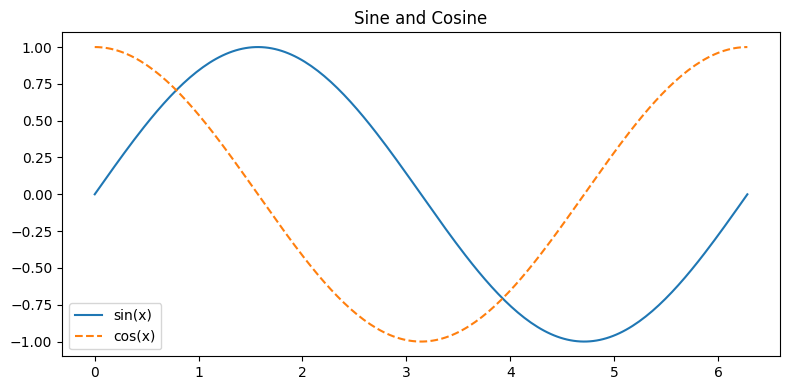

In [11]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)", linestyle="--")
ax.set_title("Sine and Cosine")
ax.legend()
plt.tight_layout()
plt.show()

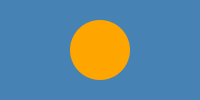

In [12]:
from IPython.display import SVG, display

display(
    SVG(
        '<svg xmlns="http://www.w3.org/2000/svg" width="200" height="100">'
        '<rect width="200" height="100" fill="steelblue"/>'
        '<circle cx="100" cy="50" r="30" fill="orange"/>'
        "</svg>"
    )
)

## 11. DataFrame output

- Run below → plain-text table with columns `name`, `score`, `grade`

In [ ]:
import pandas as pd

df = pd.DataFrame(
    {
        "name": ["Alice", "Bob", "Carol"],
        "score": [92, 87, 95],
        "grade": ["A", "B", "A"],
    }
)
df

## 12. Variable inspector

Run section 11 and the cell below first (inspection queries the kernel).

- Cursor on `df` → `<leader>kh` → float with type and value of `df`
- `<leader>kv` → float listing `df`, `summary`, `top`
  - In that float: `K` / `<CR>` on a name → inspects it; `q` / `<Esc>` closes
- `<leader>kH` → auto-hover on; rest the cursor on `top` → hover after
  ~500 ms; `<leader>kH` again → off

In [ ]:
summary = df.describe()
top = df.loc[df["score"].idxmax(), "name"]
top

## 13. LSP (pyright via the shadow buffer)

All code cells are mirrored into one shadow buffer, so symbols resolve
across cells.

- `:checkhealth vim.lsp` in Cell mode → pyright attached
- Completion → in the second cell, type `total.` → int methods offered
- `K` on `add` → hover with signature and docstring
- `<leader>lk` inside `add(` → signature help
- `<C-]>` on `add` (second cell) → jumps to its definition in the first
  cell; `<leader>ld` → preview float
- `<leader>lr` on `add` → references in both cells
- `<leader>ln` on `add` → rename to `add_ints`; both cells update
- Third cell → pyright diagnostic `"undefined_name" is not defined`;
  `]d` / `[d` jump to it
- `<leader>lss` → document symbols list `add`, `total`
- `<leader>la` → **expected** no code actions (unsupported by the plugin)
- `import numpy` resolves (no unresolved-import warning); if it does
  not, set `shadow = { location = "workspace" }`

In [ ]:
import numpy


def add(a: int, b: int) -> int:
    """Return the sum of a and b."""
    return a + b

In [ ]:
total = add(1, 2)
total

In [ ]:
undefined_name

## 14. Formatting

The plugin formats each cell through LSP (`vim.lsp.buf.format`). Only
pyright is configured for Python, and pyright does not format.

- `:NotebookFormatCell` on the cell below → **expected** no change /
  no-formatter message (with pyright only)
- `:NotebookFormatAll` → same
- With a formatting LSP attached (e.g. ruff) → cell becomes PEP 8 with no
  trailing blank lines (`format.trailing_blank_lines = 0`)

In [ ]:
x=[1,2,3]
def  square( n ):
    return n*n
y  =  list(map(square,x))
y

## 15. Cell operations (use the scratch cells below)

Start order: A, B, C. Undo everything with `u` at the end.

- On A: `dd` → A removed; on C: `p` → order B, C, A; `P` on B → A pasted
  above B
- `<M-j>` / `<M-k>` → current cell moves down / up
- `<leader>ka` / `<leader>kb` → empty cell inserted above / below
- On B: `<leader>km` → markdown; `<leader>kr` → raw; `<leader>ky` → code;
  `:NotebookToggleCellType` → toggles code ↔ markdown
- `:NotebookDeleteCell` → current cell deleted
- `<leader>kf` → current cell folds; `:NotebookFoldAll` /
  `:NotebookUnfoldAll` → all cells fold / unfold
- `u` repeatedly → back to A, B, C

In [ ]:
# scratch A

In [ ]:
# scratch B

In [ ]:
# scratch C

## 16. Markdown rendering

Treesitter highlighting applies out of the box. Rendered headings,
tables and LaTeX only appear if `ipynb` is added to render-markdown's `ft`.

### Heading level 3

**Bold**, *italic*, `inline code`, and a [link](https://github.com/ajbucci/ipynb.nvim).

- Bullet one
- Bullet two
  1. Nested numbered

| Feature | Expected |
| ------- | -------- |
| Table   | Aligned  |

Inline math $E = mc^2$ and a block:

$$
\int_0^1 x^2 \, dx = \frac{1}{3}
$$

## 17. Raw cell

- The cell below → no syntax highlighting; `<C-CR>` on it does nothing

## 18. Execute all

- Cursor on the first cell below → `:NotebookExecuteAllBelow` → both
  cells run; second prints `20`
- `:NotebookExecuteAll` runs every code cell from the top. Sections 7
  and 9 block (infinite loop, stdin), so press `<C-c>` / answer prompts

In [ ]:
a = 10

In [ ]:
b = a * 2
b

## 19. Restart and shutdown

- `<leader>k0` → kernel restarts; run the cell below → **expected**
  `NameError: name 'a' is not defined` (state cleared)
- `<leader>kS` → kernel shuts down; `<leader>kn` → DISC
- Running a cell now → warns `No kernel connected`
- `<leader>ks` → kernel starts again

In [ ]:
a

## 20. Save, round-trip and create

- `:w` (or `:NotebookSave`) → saved; `:e!` → edits and outputs persist
- Validate from a shell → no errors:

  ```bash
  uv run --with nbformat python -c \
    "import nbformat as n; n.validate(n.read('test_ipynb_nvim.ipynb', 4))"
  ```

- `:NotebookCreate /tmp/scratch.ipynb` → new empty python notebook opens
- `:NotebookSetKernel python3` → metadata kernel changes; LSP re-attaches
- `<leader>kC` then `:w` → all outputs cleared before committing